Linear Regression:
1. Create Dataset
2. Visualize it.
3. Train linear regression from scratch.
4. Track the cost.
5. Make Predictions.
6. Compare the result with scikit-learn.

Number of samples 20


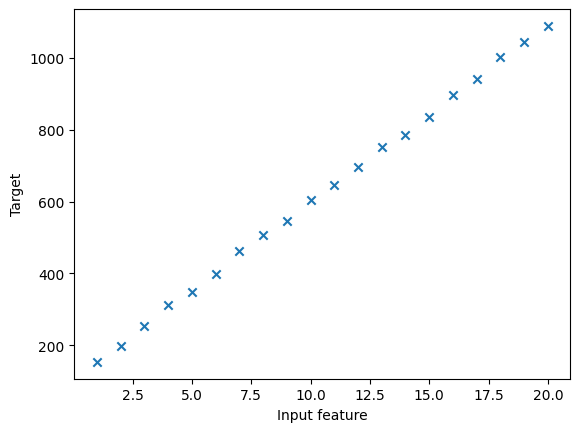

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

x_train = np.arange(1, 21, dtype = float)
noise = np.random.normal(0, 8, size = len(x_train))
y_train = 50 * x_train + 100 + noise

print('Number of samples', len(x_train))

plt.scatter(x_train, y_train, marker='x')
plt.xlabel('Input feature')
plt.ylabel('Target')
plt.show()

In [9]:
def predict(x, w, b):
  return w*x + b
def compute_cost(x, y, w, b):
  m = len(x)
  predictions = predict(x, w, b)
  errors = predictions - y
  return np.sum(errors**2) / (2*m)

def compute_gradient(x, y, w, b):
  m = len(x)
  predictions = predict(x, w, b)

  errors = predictions - y
  dw = np.sum(errors * x) / m
  db = np.sum(errors) / m

  return dw, db

def compute_gradient_descent(x, y, w, b, alpha, iterations):
  cost_history = []
  for i in range(iterations):
    dw, db = compute_gradient(x, y, w, b)
    w = w - alpha * dw
    b = b - alpha * db

    cost = compute_cost(x, y, w, b)
    cost_history.append(cost)

  return w, b, cost_history


w: 55.18857613877402
b: 25.32813452314296
cost: 790.1237703405377


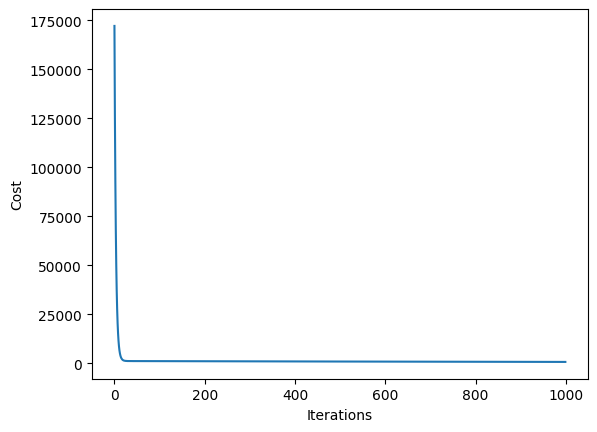

In [11]:
w = 0
b = 0

alpha = 0.001
iterations = 1000

w, b, cost_history = compute_gradient_descent(x_train, y_train, w, b, alpha, iterations)

print('w:', w)
print('b:', b)
print('cost:', cost_history[-1])

plt.plot(cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.show()

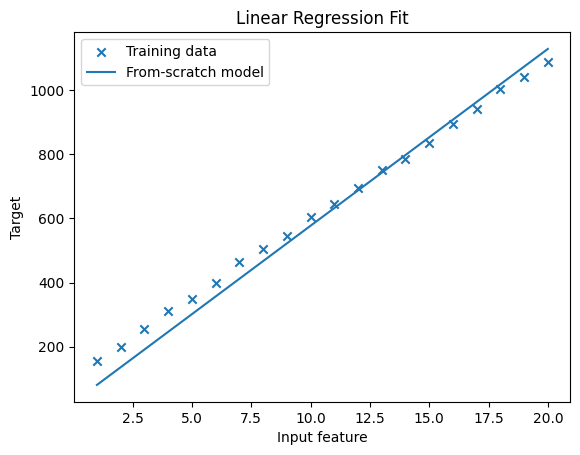

In [12]:
predictions = predict(x_train, w, b)

plt.scatter(x_train, y_train, marker='x', label='Training data')
plt.plot(x_train, predictions, label='From-scratch model')
plt.xlabel('Input feature')
plt.ylabel('Target')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

In [14]:
new_x = np.array([22.0, 25.0, 30.0])
new_predictions = predict(new_x, w, b)

for x_value, predictions in zip(new_x, new_predictions):
  print(f'Prediction for {x_value}')

Prediction for 22.0
Prediction for 25.0
Prediction for 30.0


In [15]:
from sklearn.linear_model import LinearRegression

X = x_train.reshape(-1, 1)

sk_model = LinearRegression()
sk_model.fit(X, y_train)

sk_w = sk_model.coef_[0]
sk_b = sk_model.intercept_

print(f'From scratch -> w={w:.4f}, b={b:.4f}')
print(f'Scikit-learn -> w={sk_w:.4f}, b={sk_b:.4f}')

From scratch -> w=55.1886, b=25.3281
Scikit-learn -> w=49.2035, b=106.9931


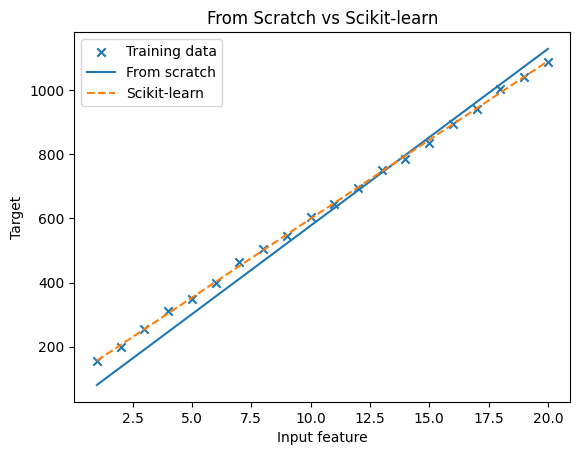

In [17]:
sk_predictions = sk_model.predict(X)
predictions = predict(x_train, w, b)

plt.scatter(x_train, y_train, marker='x', label='Training data')
plt.plot(x_train, predictions, label='From scratch')
plt.plot(x_train, sk_predictions, linestyle='--', label='Scikit-learn')
plt.xlabel('Input feature')
plt.ylabel('Target')
plt.title('From Scratch vs Scikit-learn')
plt.legend()
plt.show()

In [18]:
mse_scratch = np.mean((predictions - y_train) ** 2)
mse_sklearn = np.mean((sk_predictions - y_train) ** 2)

print(f'From-scratch MSE: {mse_scratch:.4f}')
print(f'Scikit-learn MSE: {mse_sklearn:.4f}')

From-scratch MSE: 1580.2475
Scikit-learn MSE: 34.9414


Key takeaways:
1. supervised learning and regression
2. linear model represantion
3. gradients and gradient descent
4. prediction on newer values
5. comparison between a standard ML library and from scratch representation